         Date      Open      High       Low     Close   Volume  Dividends  \
0  02-01-1962  0.050016  0.051378  0.050016  0.050016   806400        0.0   
1  03-01-1962  0.049273  0.049273  0.048159  0.048902  1574400        0.0   
2  04-01-1962  0.049026  0.049645  0.049026  0.049273   844800        0.0   
3  05-01-1962  0.049273  0.049892  0.048035  0.048159  1420800        0.0   
4  08-01-1962  0.047787  0.047787  0.046735  0.047664  2035200        0.0   

   Stock Splits  
0             0  
1             0  
2             0  
3             0  
4             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15311 entries, 0 to 15310
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          15311 non-null  object 
 1   Open          15311 non-null  float64
 2   High          15311 non-null  float64
 3   Low           15311 non-null  float64
 4   Close         15311 non-null  float64
 5   Volume        1

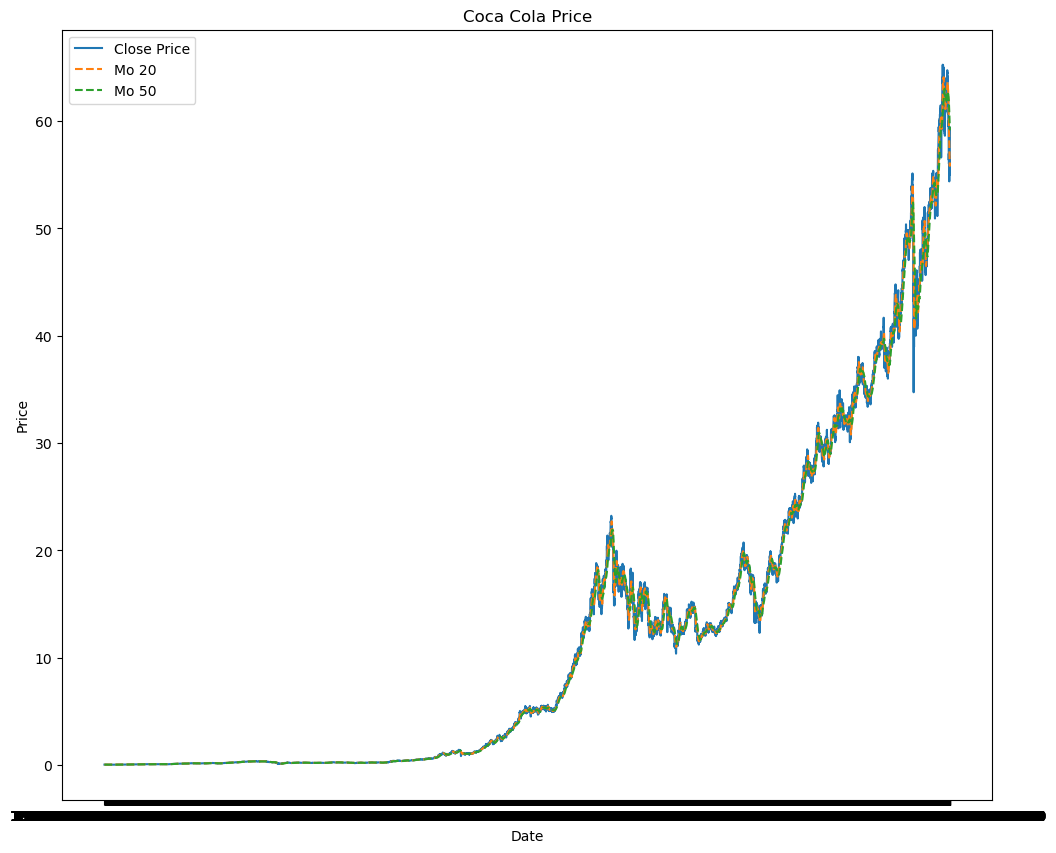

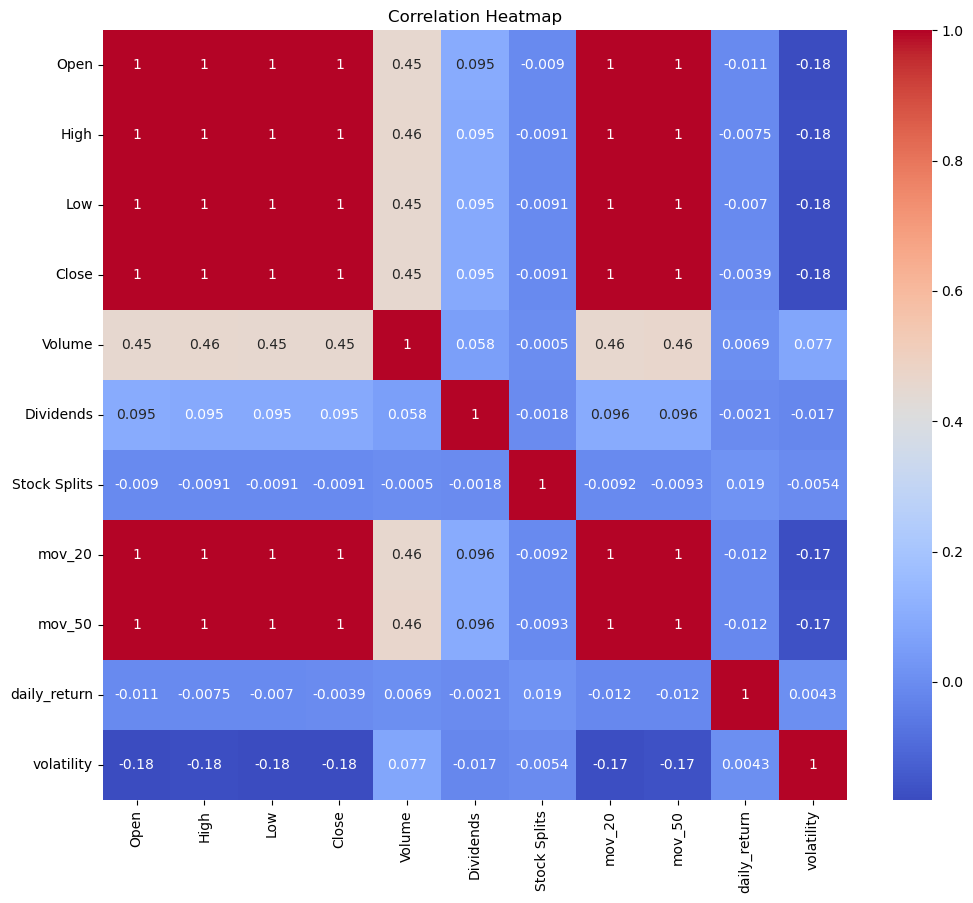

Mean Squared Error: 326.3887757321584
Mean Absolute Error:14.615874956484502


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('C:/Users/HP/Documents/DA_projects/Coca Cola/Coca_Cola_stock_history.csv')
print(df.head())
print(df.info())
print(df.columns)
print(df.isnull().sum())
# print(df)
df['mov_20'] = df['Close'].rolling(window = 20).mean()
df['mov_50'] = df['Close'].rolling(window = 50).mean()
df['daily_return'] = df['Close'].pct_change()
df['volatility'] = df['daily_return'].rolling(window=20).std()
df.dropna(inplace = True)
print(df.head())
print(df.describe())
plt.figure(figsize =(12,10))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['mov_20'], label='Mo 20', linestyle = '--')
plt.plot(df['Date'], df['mov_50'], label = 'Mo 50', linestyle= '--')
plt.title('Coca Cola Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()
plt.figure(figsize =(12,10))
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# Split the data into training and testing sets for model training.
from sklearn.model_selection import train_test_split
Features = ['Open','High','Low','Close','Volume','Dividends','Stock Splits','mov_20','mov_50','daily_return','volatility']
target = 'Close'
X = df[Features]
Y = df[target]
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42, shuffle=False)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Initialize the model
model = RandomForestRegressor(n_estimators = 100, random_state=42)
# Train the model
model.fit(X_train,Y_train)
# Predict on test set
y_pred = model.predict(X_test)
# Evaluate model
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test,y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error:{mae}")
# Fetch latest stock data
